In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Verify GPU availability
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Load and preprocess MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape for Convolutional layers (Batch, Height, Width, Channels)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

TensorFlow Version: 2.20.0
GPU Available: []
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#1. Vanilla Autoencoder (AE)
An Autoencoder maps an input to a deterministic compressed latent vector and then reconstructs it. It utilizes Mean Squared Error (MSE) to minimize reconstruction loss.

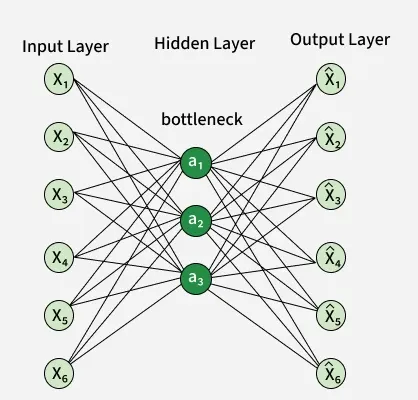

In [2]:
latent_dim = 16

# --- Encoder ---
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(128, activation="relu")(x)
latent_vector = layers.Dense(latent_dim, activation="relu")(x)
encoder = models.Model(encoder_inputs, latent_vector, name="AE_Encoder")

# --- Decoder ---
decoder_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation="relu")(decoder_inputs)
x = layers.Dense(784, activation="sigmoid")(x)
decoder_outputs = layers.Reshape((28, 28, 1))(x)
decoder = models.Model(decoder_inputs, decoder_outputs, name="AE_Decoder")

# --- Complete Autoencoder ---
ae_outputs = decoder(encoder(encoder_inputs))
autoencoder = models.Model(encoder_inputs, ae_outputs, name="Vanilla_AE")

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.fit(x_train, x_train, epochs=5, batch_size=128, validation_data=(x_test, x_test))


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0476 - val_loss: 0.0265
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0237 - val_loss: 0.0212
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0203 - val_loss: 0.0188
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0187 - val_loss: 0.0178
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0177 - val_loss: 0.0168


#2. Variational Autoencoder (VAE)

A VAE forces the latent space to map to a continuous probability distribution (a standard normal Gaussian distribution) using the reparameterization trick and KL-Divergence loss

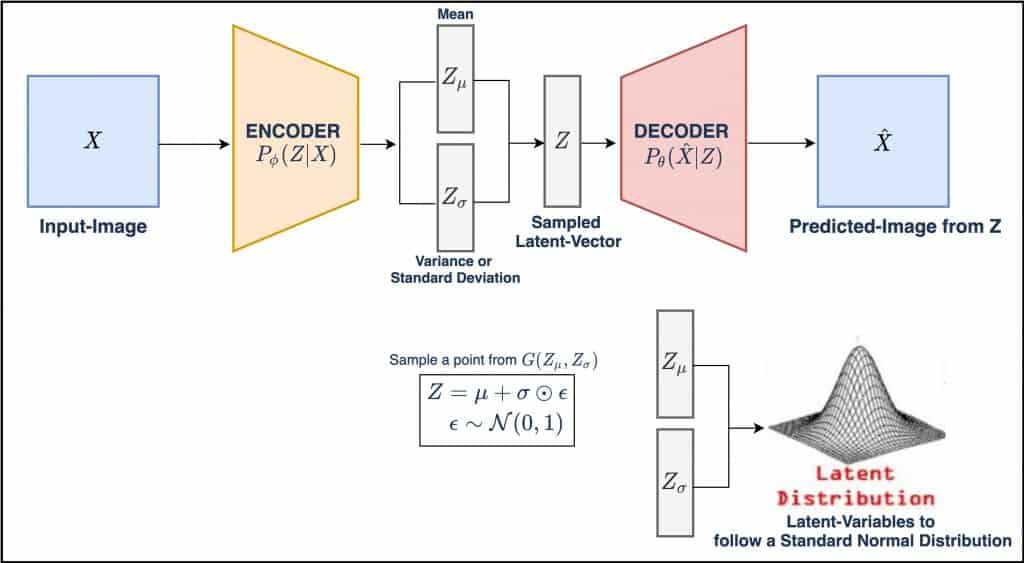

In [3]:
class VAE(models.Model):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder Architecture
        encoder_inputs = layers.Input(shape=(28, 28, 1))
        x = layers.Flatten()(encoder_inputs)
        x = layers.Dense(128, activation="relu")(x)
        z_mean = layers.Dense(latent_dim, name="z_mean")(x)
        z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
        self.encoder = models.Model(encoder_inputs, [z_mean, z_log_var], name="VAE_Encoder")

        # Decoder Architecture
        decoder_inputs = layers.Input(shape=(latent_dim,))
        x = layers.Dense(128, activation="relu")(decoder_inputs)
        x = layers.Dense(784, activation="sigmoid")(x)
        decoder_outputs = layers.Reshape((28, 28, 1))(x)
        self.decoder = models.Model(decoder_inputs, decoder_outputs, name="VAE_Decoder")

    def reparameterize(self, z_mean, z_log_var):
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(data)
            z = self.reparameterize(z_mean, z_log_var)
            reconstruction = self.decoder(z)

            # Loss computations
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "recon_loss": reconstruction_loss, "kl_loss": kl_loss}

# Instantiate and train VAE
vae = VAE(latent_dim=2)
vae.compile(optimizer=tf.keras.optimizers.Adam())
vae.fit(x_train, epochs=5, batch_size=128)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - kl_loss: 5.2853 - loss: 183.6087 - recon_loss: 178.3234 
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 4.6292 - loss: 173.2232 - recon_loss: 168.5939
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 4.9500 - loss: 168.8096 - recon_loss: 163.8596
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 4.5782 - loss: 165.1088 - recon_loss: 160.5306
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.0004 - loss: 169.0094 - recon_loss: 164.0090


#3. Generative Adversarial Network (GAN)

A GAN skips reconstruction completely. It relies on a min-max game where a Generator learns to create fake images out of pure noise, while a Discriminator learns to classify real versus fake images

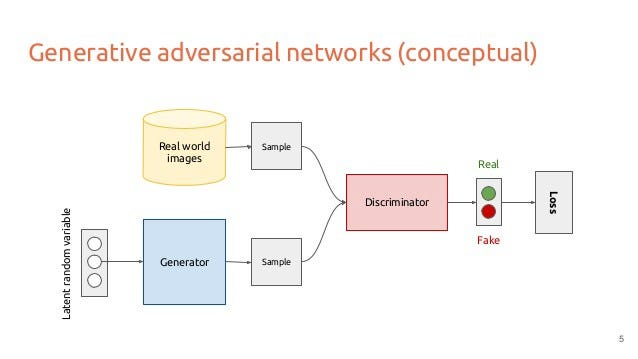

In [4]:
noise_dim = 100

# --- Generator ---
def make_generator():
    model = models.Sequential([
        layers.Input(shape=(noise_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(784, activation='sigmoid'),
        layers.Reshape((28, 28, 1))
    ], name="Generator")
    return model

# --- Discriminator ---
def make_discriminator():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ], name="Discriminator")
    return model

generator = make_generator()
discriminator = make_discriminator()

# --- Custom GAN Training Loop ---
cross_entropy = tf.keras.losses.BinaryCrossentropy()
gen_optimizer = tf.keras.optimizers.Adam(1e-4)
disc_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_gan_step(images, batch_size):
    noise = tf.random.normal([batch_size, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Calculate Losses
        disc_loss = cross_entropy(tf.ones_like(real_output), real_output) + \
                    cross_entropy(tf.zeros_like(fake_output), fake_output)
        gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)

    # Backpropagation
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

# Execute Loop on mini-batches
batch_size = 128
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(60000).batch(batch_size)

for epoch in range(5):
    for image_batch in dataset:
        train_gan_step(image_batch, tf.shape(image_batch)[0])
    print(f"Epoch {epoch+1} completed.")


Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.
Epoch 4 completed.
Epoch 5 completed.


#Output

Images generated via GAN:


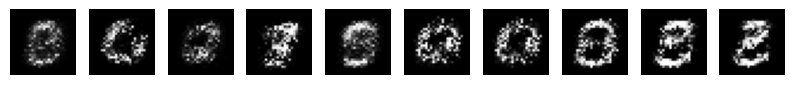

In [5]:
# Function to generate and display results from GAN/VAE
def plot_generated_images(model_type="GAN"):
    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1, 10, i+1)
        if model_type == "GAN":
            noise = tf.random.normal([1, noise_dim])
            img = generator(noise, training=False)
        else: # VAE
            random_latent = tf.random.normal([1, 2])
            img = vae.decoder(random_latent, training=False)

        plt.imshow(img[0, :, :, 0], cmap='gray')
        plt.axis('off')
    plt.show()

print("Images generated via GAN:")
plot_generated_images(model_type="GAN")


The images generated by the GAN (Generative Adversarial Network) are synthetic images created by the Generator model. In this context, the GAN was trained on the MNIST dataset, which consists of handwritten digits. Therefore, the generated images are attempts by the Generator to produce new, unseen handwritten digits that are similar in style and characteristics to the real MNIST digits it was trained on. They signify the Generator's ability to learn and mimic the data distribution of the training set, essentially creating 'fake' but realistic-looking data.